<a href="https://colab.research.google.com/github/matheus-cmc/atividades_IA_industrial/blob/main/Atividade_2_previs%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")

from google.colab import files

uploaded=files.upload()
df=pd.read_csv("atividade2 - flights_100.csv")

print("Dimensão do dataset:", df.shape)
display(df.head())
df.info()

print("\nValores ausentes por coluna")
print(df.isnull().sum())

Saving atividade2 - flights_100.csv to atividade2 - flights_100 (2).csv
Dimensão do dataset: (100, 9)


,FL_DATE,OP_UNIQUE_CARRIER,TAIL_NUM,ORIGIN,DEST,CRS_DEP_TIME,DEP_DELAY,ARR_DELAY,DISTANCE
0,2023-01-01,AZUL,N1000,GIG,FOR,1369,7.0,32.0,4984
1,2023-01-02,SW,N1001,BSB,MIA,1986,-42.0,-38.0,4200
2,2023-01-03,LATAM,N1002,ORD,REC,1534,-30.0,21.0,1833
3,2023-01-04,AZUL,N1003,JFK,FOR,146,-39.0,52.0,2352
4,2023-01-05,UA,N1004,GIG,SFO,1734,-24.0,42.0,710


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   FL_DATE            100 non-null    object 
 1   OP_UNIQUE_CARRIER  100 non-null    object 
 2   TAIL_NUM           100 non-null    object 
 3   ORIGIN             100 non-null    object 
 4   DEST               100 non-null    object 
 5   CRS_DEP_TIME       100 non-null    int64  
 6   DEP_DELAY          90 non-null     float64
 7   ARR_DELAY          90 non-null     float64
 8   DISTANCE           100 non-null    int64  
dtypes: float64(2), int64(2), object(5)
memory usage: 7.2+ KB

Valores ausentes por coluna
FL_DATE               0
OP_UNIQUE_CARRIER     0
TAIL_NUM              0
ORIGIN                0
DEST                  0
CRS_DEP_TIME          0
DEP_DELAY            10
ARR_DELAY            10
DISTANCE              0
dtype: int64


In [ ]:
col_numericas=df.select_dtypes(include=['int64', 'float64']).columns.tolist()
col_categoricas=df.select_dtypes(include=['object']).columns.tolist()

print("Colunas Numéricas:",col_numericas)
print("Colunas Categóricas:",col_categoricas)

print("\nEstatísticas descritivas (numéricas):")
display(df[col_numericas].describe().T)

amplitude=(df[col_numericas].max()-df[col_categoricas])
print("\nAmplitude das vaiáves númericas:")
print(amplitude)

Colunas Numéricas: ['CRS_DEP_TIME', 'DEP_DELAY', 'ARR_DELAY', 'DISTANCE']
Colunas Categóricas: ['FL_DATE', 'OP_UNIQUE_CARRIER', 'TAIL_NUM', 'ORIGIN', 'DEST']

Estatísticas descritivas (numéricas):


,count,mean,std,min,25%,50%,75%,max
CRS_DEP_TIME,100.0,1242.930000,686.193250,16.0,626.00,1230.5,1812.25,2331.0
DEP_DELAY,90.0,9.066667,33.684525,-57.0,-15.00,7.0,33.25,106.0
ARR_DELAY,90.0,7.688889,39.095574,-103.0,-20.50,6.0,36.25,90.0
DISTANCE,100.0,2897.620000,1420.354052,337.0,1859.25,2940.0,4266.00,4984.0



Amplitude das vaiáves númericas:
    ARR_DELAY  CRS_DEP_TIME  DEP_DELAY DEST  DISTANCE FL_DATE  \
0         NaN           NaN        NaN  NaN       NaN     NaN   
1         NaN           NaN        NaN  NaN       NaN     NaN   
2         NaN           NaN        NaN  NaN       NaN     NaN   
3         NaN           NaN        NaN  NaN       NaN     NaN   
4         NaN           NaN        NaN  NaN       NaN     NaN   
..        ...           ...        ...  ...       ...     ...   
95        NaN           NaN        NaN  NaN       NaN     NaN   
96        NaN           NaN        NaN  NaN       NaN     NaN   
97        NaN           NaN        NaN  NaN       NaN     NaN   
98        NaN           NaN        NaN  NaN       NaN     NaN   
99        NaN           NaN        NaN  NaN       NaN     NaN   

   OP_UNIQUE_CARRIER ORIGIN TAIL_NUM  
0                NaN    NaN      NaN  
1                NaN    NaN      NaN  
2                NaN    NaN      NaN  
3                NaN    NaN  

In [ ]:
if 'FlightDate' in df.columns:
   df['FlightDate'] = pd.to_datetime(df['FlightDate'])

   df[cod_categoricas]= df[cod_categoricas].apply(lambda x: x.str.strip())

if 'ARR_DELAY' in df.columns:
       df['Delay>15'] = np.where(df['ARR_DELAY'] > 15, 1, 0)
       print("\nProporção de atrasos > 15 min:", df['Delay>15'].mean())

if 'ARR_DELAY' in df.columns:
    Q1 = df['ARR_DELAY'].quantile(0.25)
    Q3 = df['ARR_DELAY'].quantile(0.75)
    IQR = Q3 - Q1
    limites = (Q1 - 1.5*IQR, Q3 + 1.5*IQR)
    outliers = df[(df['ARR_DELAY'] < limites[0]) | (df['ARR_DELAY'] > limites[1])]
    print(f"\nQtd de outliers em ARR_DELAY: {len(outliers)} ({100*len(outliers)/len(df):.2f}%)")


Proporção de atrasos > 15 min: 0.38

Qtd de outliers em ARR_DELAY: 0 (0.00%)


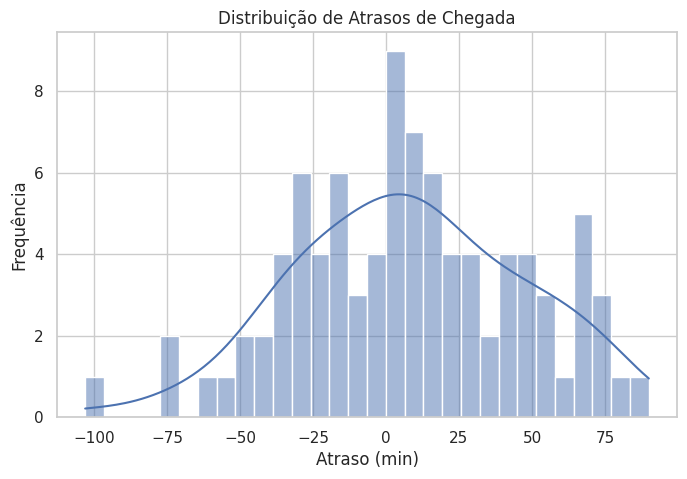

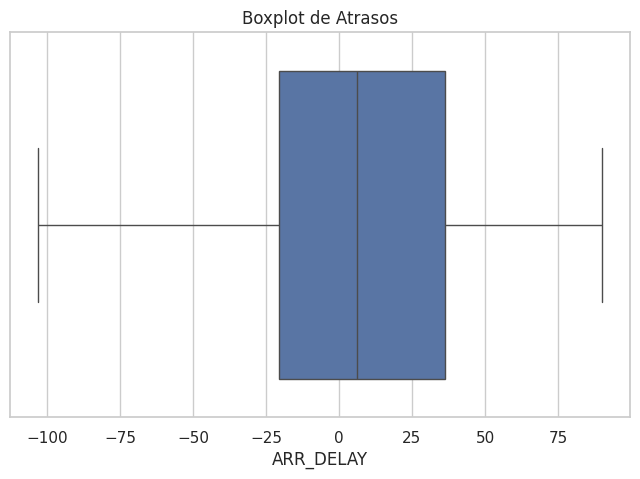

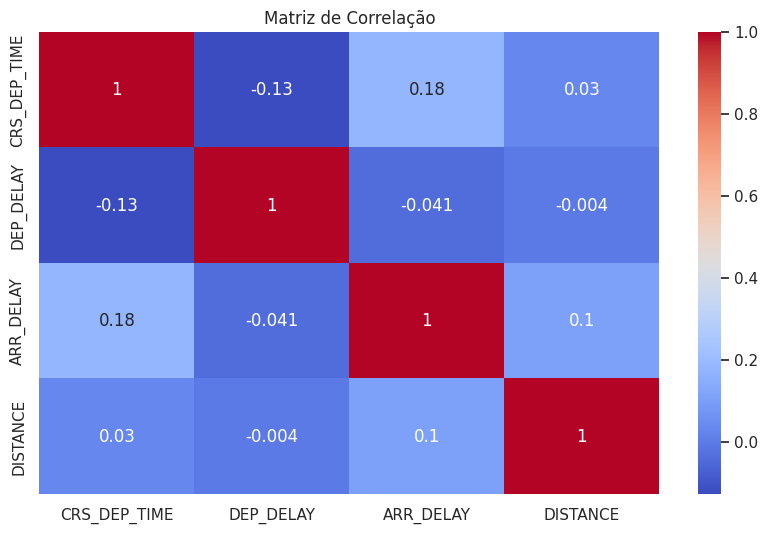


Dataset limpo salvo como flights_clean.csv


In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['ARR_DELAY'], bins=30, kde=True)
plt.title("Distribuição de Atrasos de Chegada")
plt.xlabel("Atraso (min)")
plt.ylabel("Frequência")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x=df['ARR_DELAY'])
plt.title("Boxplot de Atrasos")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df[col_numericas].corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.show()

df.to_csv("flights_clean.csv", index=False)
print("\nDataset limpo salvo como flights_clean.csv")